# WHAT CHANGED IN THIS RUN

**Change:**
criterion = nn.CrossEntropyLoss()

**To:**
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

**Because:**
m1 saw same overfitting pattern as v16A. Val loss bottoms out around epoch 2 and then climbs steadily while training loss keeps dropping. By epoch 11 the gap is ~15%. The geo features helped accuracy slightly but did nothing for the overfitting problem — the model is still memorizing after the first couple epochs.

The best model checkpoint was probably saved at epoch 2 or 3 (wherever val loss was lowest), which means the model barely got to use the geometric features before overfitting took over. The geo MLP needs more training time at low loss to learn meaningful representations, but the CNN is memorizing too fast for that to happen.

Label smoothing softens the targets so the model can't be as confident about memorized examples.

# GazeNet v17 — Training Notebook (Colab)

GazeNet with geometric feature branch (iris ratios, head pose, z-depth).

**Prerequisites:**
- Google Drive contains: `210/gaze_wds_balanced/`, `210/gaze_labels.csv`, `210/geo_features_v1.parquet`
- Runtime set to **T4 GPU**

In [ ]:
# ============================================================
# INSTALL & MOUNT
# ============================================================
!pip install webdataset -q

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

True
NVIDIA A100-SXM4-40GB


In [4]:
# ============================================================
# ALL PATHS — everything references these variables
# ============================================================

TAR_DIR         = "/content/gaze_wds_balanced"
LABELS_CSV      = "/content/drive/MyDrive/210/gaze_labels.csv"
GEO_PARQUET     = "/content/drive/MyDrive/210/geo_features_v1.parquet"
CHECKPOINT_PATH = '/content/drive/MyDrive/210/m2.pth'

In [5]:
# ============================================================
# IMPORTS
# ============================================================

import os, glob, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import webdataset as wds
from torchvision import transforms
from sklearn.metrics import confusion_matrix, classification_report

print("Imports loaded")

Imports loaded


In [6]:
# ============================================================
# COPY TARS TO LOCAL COLAB DISK (~10 min)
# Reading from Drive during training is slow, so we copy first.
# ============================================================

for split in ['train', 'val', 'test']:
    local_dir = f'/content/gaze_wds_balanced/{split}'
    os.makedirs(local_dir, exist_ok=True)
    source = f'/content/drive/MyDrive/210/gaze_wds_balanced/{split}/'
    tar_files = sorted(glob.glob(source + '*.tar'))
    for f in tar_files:
        fname = os.path.basename(f)
        dest = f"{local_dir}/{fname}"
        if not os.path.exists(dest):
            os.system(f"cp '{f}' '{dest}'")
    count = len([f for f in os.listdir(local_dir) if f.endswith('.tar')])
    print(f"{split}: {count} tars copied")

train: 75 tars copied
val: 16 tars copied
test: 16 tars copied


In [7]:
# ============================================================
# VERIFY FILES
# ============================================================

train_tar_urls = sorted(glob.glob(f"{TAR_DIR}/train/*.tar"))
val_tar_urls   = sorted(glob.glob(f"{TAR_DIR}/val/*.tar"))
test_tar_urls  = sorted(glob.glob(f"{TAR_DIR}/test/*.tar"))

print(f"Train tars: {len(train_tar_urls)}")
print(f"Val tars:   {len(val_tar_urls)}")
print(f"Test tars:  {len(test_tar_urls)}")
print(f"Labels CSV: {os.path.exists(LABELS_CSV)}")
print(f"Geo parquet: {os.path.exists(GEO_PARQUET)}")

Train tars: 75
Val tars:   16
Test tars:  16
Labels CSV: True
Geo parquet: True


In [8]:
# ============================================================
# LOAD LABELS → label_lookup dict
# Maps sample key (e.g. "00003_000000") to label string
# ============================================================

label_map = {'Straight': 0, 'Up': 1, 'Down': 2, 'Left': 3, 'Right': 4}

df_labels = pd.read_csv(LABELS_CSV, dtype={'subject_id': str})
print(f"Loaded {len(df_labels)} labeled frames")

label_lookup = {}
for _, row in df_labels.iterrows():
    key = f"{row['subject_id']}_{int(row['frame_idx']):06d}"
    label_lookup[key] = row['label']

print(f"Label lookup: {len(label_lookup)} entries")

Loaded 849131 labeled frames
Label lookup: 849131 entries


In [9]:
# ============================================================
# LOAD GEO FEATURES → geo_lookup dict
# Maps sample key to numpy array of 7 features.
# Precomputed locally with MediaPipe, uploaded to Drive.
# ============================================================

df_geo = pd.read_parquet(GEO_PARQUET)
print(f"Loaded geo features: {len(df_geo)} rows")

geo_cols = ['left_iris_h', 'right_iris_h', 'iris_h_agreement',
            'head_yaw', 'head_pitch', 'z_tilt', 'z_nose_rel']

geo_lookup = {}
for _, row in df_geo.iterrows():
    features = row[geo_cols].values.astype(np.float32)
    geo_lookup[row['key']] = features

print(f"Geo lookup: {len(geo_lookup)} entries")

# Neutral default for samples missing from geo_lookup
# (roughly dataset means)
GEO_DEFAULT = np.array([0.5, 0.5, 0.0, 0.0, 0.35, -0.1, -0.26], dtype=np.float32)
print(f"Geo default: {GEO_DEFAULT}")

Loaded geo features: 273462 rows
Geo lookup: 273462 entries
Geo default: [ 0.5   0.5   0.    0.    0.35 -0.1  -0.26]


In [10]:
# ============================================================
# IMAGE TRANSFORMS
#
# Training: augmentation (color jitter, grayscale, blur)
# Val/Test: clean (just resize and normalize)
#
# Eye images: resize to 48x48 (from 60x36 raw)
# Face images: already 112x112, no resize needed
# Normalization: mean=0.5, std=0.5 for all channels
# ============================================================

# ---- Training transforms (with augmentation) ----
eye_transform_aug = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((48, 48)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomGrayscale(p=0.1),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

face_transform_aug = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomGrayscale(p=0.1),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# ---- Val/Test transforms (no augmentation) ----
eye_transform_clean = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

face_transform_clean = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

print("Transforms defined")

Transforms defined


In [11]:
# ============================================================
# MAKE_DATASET: WebDataset pipeline with geo features
#
# Changes from v16A:
#   - Looks up geo_features from geo_lookup dict
#   - Returns geo_features tensor alongside images and label
#   - Falls back to GEO_DEFAULT if sample key not in geo_lookup
# ============================================================

def make_dataset(tar_urls, eye_transform, face_transform, shuffle=True):
    """Create a WebDataset pipeline that returns images + geo features."""

    def filter_and_transform(sample):
        key = sample["__key__"]

        # ---- Label lookup (same as v16A) ----
        label_str = label_lookup.get(key)
        if label_str is None:
            return None

        # ---- Image transforms (same as v16A) ----
        face = np.array(sample["face.jpg"])
        left_eye = np.array(sample["left.jpg"])
        right_eye = np.array(sample["right.jpg"])

        if eye_transform:
            left_eye = eye_transform(left_eye)
            right_eye = eye_transform(right_eye)
        if face_transform:
            face = face_transform(face)

        # ---- NEW: geo feature lookup ----
        geo_features = geo_lookup.get(key)
        if geo_features is None:
            geo_features = GEO_DEFAULT.copy()

        label_idx = label_map[label_str]

        return {
            'left_eye': left_eye,
            'right_eye': right_eye,
            'face': face,
            'geo_features': torch.tensor(geo_features, dtype=torch.float32),
            'label': torch.tensor(label_idx, dtype=torch.long),
        }

    dataset = (
        wds.WebDataset(tar_urls, shardshuffle=1000 if shuffle else False)
        .shuffle(50000 if shuffle else 0)
        .decode("pil")
        .map(filter_and_transform)
        .select(lambda x: x is not None)
    )

    return dataset

print("make_dataset defined")

make_dataset defined


In [12]:
# ============================================================
# GazeNetV17 — Model Definition
#
# Same CNN streams as v16A GazeNet, plus a small MLP branch
# that processes our 7 geometric features.
#
# Architecture:
#   left_eye image  -> Eye CNN (shared weights) -> 4608 dims -+
#   right_eye image -> Eye CNN (shared weights) -> 4608 dims -+
#   face image      -> Face CNN                 -> 2304 dims -+
#   7 geo features  -> MLP (7->64->64)          ->   64 dims -+  <- NEW
#                                                             +-> FC -> 5 classes
#                                                    total: 11584
# ============================================================

class GazeNetV17(nn.Module):
    def __init__(self, num_classes=5, geo_feat_dim=7):
        super(GazeNetV17, self).__init__()

        # ---- Eye CNN (shared weights for left and right) ----
        # Input: (batch, 3, 48, 48) -> Output: (batch, 128, 6, 6)
        # UNCHANGED from v16A
        self.eye_cnn = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),   # 48x48 -> 48x48
            nn.ReLU(),
            nn.MaxPool2d(2),                               # -> 24x24

            nn.Conv2d(32, 64, kernel_size=3, padding=1),   # -> 24x24
            nn.ReLU(),
            nn.MaxPool2d(2),                               # -> 12x12

            nn.Conv2d(64, 128, kernel_size=3, padding=1),  # -> 12x12
            nn.ReLU(),
            nn.MaxPool2d(2),                               # -> 6x6
        )
        # Flattened: 128 * 6 * 6 = 4608 per eye

        # ---- Face CNN ----
        # Input: (batch, 3, 112, 112) -> Output: (batch, 256, 3, 3)
        # UNCHANGED from v16A
        self.face_cnn = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=7, stride=2, padding=3),  # 112->56
            nn.ReLU(),
            nn.MaxPool2d(2),                                        # ->28

            nn.Conv2d(32, 64, kernel_size=5, padding=2),            # ->28
            nn.ReLU(),
            nn.MaxPool2d(2),                                        # ->14

            nn.Conv2d(64, 128, kernel_size=3, padding=1),           # ->14
            nn.ReLU(),
            nn.MaxPool2d(2),                                        # ->7

            nn.Conv2d(128, 256, kernel_size=3, padding=1),          # ->7
            nn.ReLU(),
            nn.MaxPool2d(2),                                        # ->3
        )
        # Flattened: 256 * 3 * 3 = 2304

        # ---- NEW: Geometric feature branch ----
        # Takes our 7 hand-crafted features and maps them to 64 dims
        # so they're meaningful alongside the ~11K CNN features
        self.geo_mlp = nn.Sequential(
            nn.Linear(geo_feat_dim, 64),   # 7 -> 64
            nn.ReLU(),
            nn.Dropout(0.3),               # lighter dropout than FC layers
            nn.Linear(64, 64),             # 64 -> 64
            nn.ReLU(),
        )

        # ---- FC classifier ----
        # Concatenated input: 4608 + 4608 + 2304 + 64 = 11584
        self.fc = nn.Sequential(
            nn.Linear(4608 * 2 + 2304 + 64, 512),  # 11584 -> 512
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(512, 256),                     # 512 -> 256
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(256, num_classes),              # 256 -> 5
        )

    def forward(self, left_eye, right_eye, face, geo_features):
        # ---- CNN streams (unchanged from v16A) ----
        left_feat  = self.eye_cnn(left_eye).view(left_eye.size(0), -1)    # -> 4608
        right_feat = self.eye_cnn(right_eye).view(right_eye.size(0), -1)  # -> 4608
        face_feat  = self.face_cnn(face).view(face.size(0), -1)           # -> 2304

        # ---- NEW: geometric feature branch ----
        geo_feat = self.geo_mlp(geo_features)  # -> 64

        # ---- Concatenate all four streams and classify ----
        combined = torch.cat([left_feat, right_feat, face_feat, geo_feat], dim=1)  # -> 11584
        return self.fc(combined)

print("GazeNetV17 defined")

GazeNetV17 defined


In [13]:
# ============================================================
# CREATE DATASETS AND DATALOADERS
# Train: augmented transforms, shuffled
# Val/Test: clean transforms, no shuffle
# ============================================================

train_dataset = make_dataset(train_tar_urls, eye_transform_aug,   face_transform_aug,   shuffle=True)
val_dataset   = make_dataset(val_tar_urls,   eye_transform_clean, face_transform_clean, shuffle=False)
test_dataset  = make_dataset(test_tar_urls,  eye_transform_clean, face_transform_clean, shuffle=False)

train_loader = wds.WebLoader(train_dataset, batch_size=32, num_workers=2, pin_memory=True)
val_loader   = wds.WebLoader(val_dataset,   batch_size=32, num_workers=2, pin_memory=True)
test_loader  = wds.WebLoader(test_dataset,  batch_size=32, num_workers=2, pin_memory=True)

print("Datasets and loaders ready")

Datasets and loaders ready


In [14]:
# ============================================================
# MODEL, LOSS, OPTIMIZER, SCHEDULER
# Same hyperparameters as v16A:
#   - lr: 1e-4
#   - weight_decay: 5e-4
#   - scheduler: ReduceLROnPlateau, patience=3
#   - early stopping: patience=6
# ============================================================

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = GazeNetV17(num_classes=5).to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=5e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.5
)

print("Model, loss, optimizer, scheduler ready")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Using device: cuda
Model, loss, optimizer, scheduler ready
Parameters: 6,587,077


In [15]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

True
NVIDIA A100-SXM4-40GB


In [16]:
# ============================================================
# SMOKE TEST: Run one batch through the full pipeline
# Confirms: tar loading -> image transforms -> geo lookup -> model forward pass
# ============================================================

test_tar = [train_tar_urls[0]]
print(f"Testing with: {test_tar[0]}")

test_ds = make_dataset(test_tar, eye_transform_clean, face_transform_clean, shuffle=False)
smoke_loader = wds.WebLoader(test_ds, batch_size=4, num_workers=0)

batch = next(iter(smoke_loader))

print(f"\nBatch contents:")
print(f"  left_eye:     {batch['left_eye'].shape}")
print(f"  right_eye:    {batch['right_eye'].shape}")
print(f"  face:         {batch['face'].shape}")
print(f"  geo_features: {batch['geo_features'].shape}")
print(f"  label:        {batch['label'].shape}")

model.eval()
with torch.no_grad():
    outputs = model(
        batch['left_eye'].to(device),
        batch['right_eye'].to(device),
        batch['face'].to(device),
        batch['geo_features'].to(device),
    )

print(f"\nModel output: {outputs.shape}")
print(f"Pipeline works end-to-end!")

Testing with: /content/gaze_wds_balanced/train/gaze-train-000000.tar

Batch contents:
  left_eye:     torch.Size([4, 3, 48, 48])
  right_eye:    torch.Size([4, 3, 48, 48])
  face:         torch.Size([4, 3, 112, 112])
  geo_features: torch.Size([4, 7])
  label:        torch.Size([4])

Model output: torch.Size([4, 5])
Pipeline works end-to-end!


In [17]:
# ============================================================
# TRAINING LOOP
#
# Same structure as v16A with two changes:
#   1. geo_features extracted from batch and passed to model
#   2. Model checkpoint saved as best_gazenet_v17.pth
# ============================================================

num_epochs = 20
best_val_loss = float('inf')

# Early stopping
patience = 6
patience_counter = 0

# Track metrics for loss curves
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):
    print(f"\n{'='*50}")
    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"{'='*50}")

    # ============================================
    # TRAINING PHASE
    # ============================================
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    epoch_start = time.time()

    for batch_idx, batch in enumerate(train_loader):
        # Move data to device
        left_eye     = batch['left_eye'].to(device)
        right_eye    = batch['right_eye'].to(device)
        face         = batch['face'].to(device)
        geo_features = batch['geo_features'].to(device)
        labels       = batch['label'].to(device)

        # Forward pass
        optimizer.zero_grad()
        outputs = model(left_eye, right_eye, face, geo_features)
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()
        optimizer.step()

        # Track metrics
        train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

        # Print progress every 1000 batches
        if (batch_idx + 1) % 1000 == 0:
            elapsed = time.time() - epoch_start
            batches_done = batch_idx + 1
            eta_minutes = (elapsed / batches_done) * (7000 - batches_done) / 60
            print(f"  Batch {batches_done}/~7000 - Loss: {loss.item():.4f} - ETA: {eta_minutes:.1f} min")

    # Calculate training metrics
    avg_train_loss = train_loss / (batch_idx + 1)
    train_acc = 100 * train_correct / train_total
    epoch_time = time.time() - epoch_start

    # ============================================
    # VALIDATION PHASE
    # ============================================
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    val_batch_count = 0

    with torch.no_grad():
        for batch in val_loader:
            val_batch_count += 1
            left_eye     = batch['left_eye'].to(device)
            right_eye    = batch['right_eye'].to(device)
            face         = batch['face'].to(device)
            geo_features = batch['geo_features'].to(device)
            labels       = batch['label'].to(device)

            outputs = model(left_eye, right_eye, face, geo_features)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    # Calculate validation metrics
    avg_val_loss = val_loss / val_batch_count
    val_acc = 100 * val_correct / val_total

    # Save metrics
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    # Step scheduler
    scheduler.step(avg_val_loss)

    # Print epoch summary
    print(f"\n  Time: {epoch_time/60:.1f} min")
    print(f"  Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"  Val Loss:   {avg_val_loss:.4f} | Val Acc:   {val_acc:.2f}%")
    print(f"  Gap: {train_acc - val_acc:.2f}%")

    # Save best model
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), CHECKPOINT_PATH)
        print(f"  Saved best model (val_loss={avg_val_loss:.4f})")
        patience_counter = 0
    else:
        patience_counter += 1
        print(f"  No improvement ({patience_counter}/{patience})")

    # Early stopping
    if patience_counter >= patience:
        print(f"\nEarly stopping triggered at epoch {epoch+1}")
        break

print(f"\nTraining complete!")
print(f"Best validation loss: {best_val_loss:.4f}")


Epoch 1/20
  Batch 1000/~7000 - Loss: 0.9935 - ETA: 12.5 min
  Batch 2000/~7000 - Loss: 0.9592 - ETA: 10.4 min
  Batch 3000/~7000 - Loss: 0.9171 - ETA: 8.2 min
  Batch 4000/~7000 - Loss: 1.0490 - ETA: 6.0 min
  Batch 5000/~7000 - Loss: 0.9783 - ETA: 4.0 min
  Batch 6000/~7000 - Loss: 0.8545 - ETA: 2.0 min

  Time: 12.4 min
  Train Loss: 0.9773 | Train Acc: 68.47%
  Val Loss:   0.8615 | Val Acc:   74.59%
  Gap: -6.12%
  Saved best model (val_loss=0.8615)

Epoch 2/20
  Batch 1000/~7000 - Loss: 0.7574 - ETA: 12.4 min
  Batch 2000/~7000 - Loss: 0.8668 - ETA: 10.3 min
  Batch 3000/~7000 - Loss: 0.7582 - ETA: 8.2 min
  Batch 4000/~7000 - Loss: 0.8549 - ETA: 6.0 min
  Batch 5000/~7000 - Loss: 0.7664 - ETA: 4.0 min
  Batch 6000/~7000 - Loss: 0.6574 - ETA: 2.0 min

  Time: 12.4 min
  Train Loss: 0.8123 | Train Acc: 78.23%
  Val Loss:   0.8317 | Val Acc:   75.96%
  Gap: 2.26%
  Saved best model (val_loss=0.8317)

Epoch 3/20
  Batch 1000/~7000 - Loss: 0.6171 - ETA: 12.6 min
  Batch 2000/~7000 - 

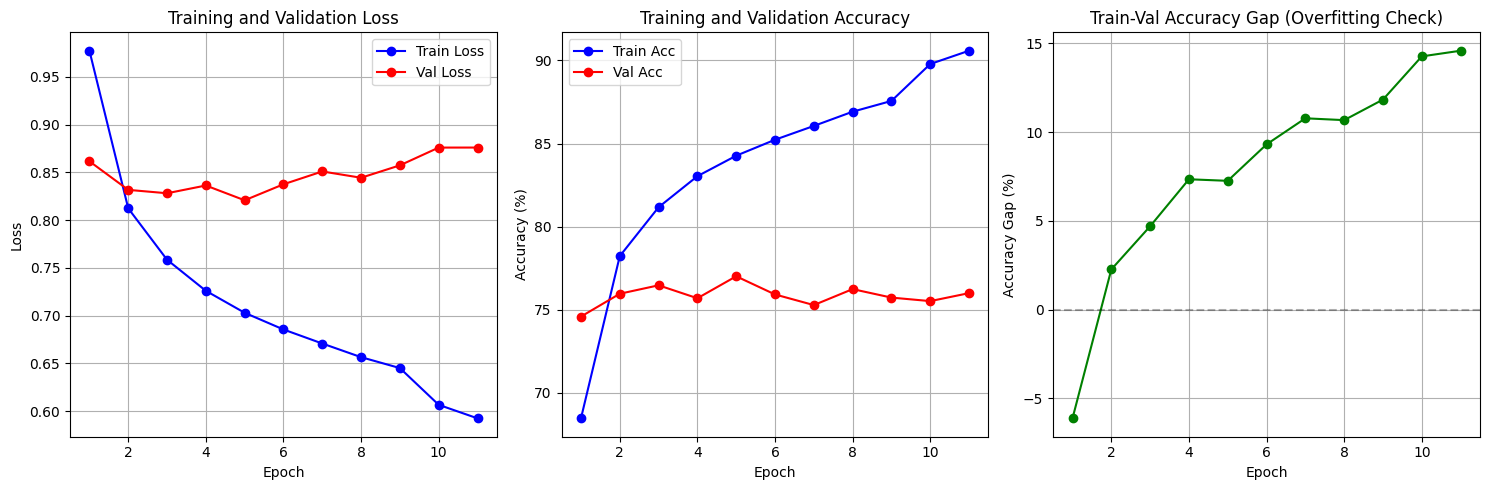


Total epochs: 11
Best val loss: 0.8208 (Epoch 5)
Best val acc:  77.01% (Epoch 5)
Final gap:     14.59%


In [18]:
# ============================================================
# LOSS CURVES
# Same plots as v16A: loss, accuracy, and train-val gap
# ============================================================

plt.figure(figsize=(15, 5))

# ---- Loss ----
plt.subplot(1, 3, 1)
plt.plot(range(1, len(train_losses) + 1), train_losses, 'b-o', label='Train Loss')
plt.plot(range(1, len(val_losses) + 1), val_losses, 'r-o', label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

# ---- Accuracy ----
plt.subplot(1, 3, 2)
plt.plot(range(1, len(train_accuracies) + 1), train_accuracies, 'b-o', label='Train Acc')
plt.plot(range(1, len(val_accuracies) + 1), val_accuracies, 'r-o', label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)

# ---- Overfitting gap ----
plt.subplot(1, 3, 3)
gap = [train_accuracies[i] - val_accuracies[i] for i in range(len(train_accuracies))]
plt.plot(range(1, len(gap) + 1), gap, 'g-o')
plt.xlabel('Epoch')
plt.ylabel('Accuracy Gap (%)')
plt.title('Train-Val Accuracy Gap (Overfitting Check)')
plt.axhline(y=0, color='k', linestyle='--', alpha=0.3)
plt.grid(True)

plt.tight_layout()
plt.show()

# ---- Summary ----
print(f"\nTotal epochs: {len(train_losses)}")
print(f"Best val loss: {min(val_losses):.4f} (Epoch {val_losses.index(min(val_losses)) + 1})")
print(f"Best val acc:  {max(val_accuracies):.2f}% (Epoch {val_accuracies.index(max(val_accuracies)) + 1})")
print(f"Final gap:     {train_accuracies[-1] - val_accuracies[-1]:.2f}%")

In [19]:
# Print summary
print("\n" + "="*50)
print("Training Summary")
print("="*50)
print(f"Total epochs completed: {len(train_losses)}")
print(f"Best validation loss: {min(val_losses):.4f} (Epoch {val_losses.index(min(val_losses)) + 1})")
print(f"Best validation accuracy: {max(val_accuracies):.2f}% (Epoch {val_accuracies.index(max(val_accuracies)) + 1})")
print(f"Final train accuracy: {train_accuracies[-1]:.2f}%")
print(f"Final val accuracy: {val_accuracies[-1]:.2f}%")
print(f"Final train-val gap: {train_accuracies[-1] - val_accuracies[-1]:.2f}%")
print("="*50)


Training Summary
Total epochs completed: 11
Best validation loss: 0.8208 (Epoch 5)
Best validation accuracy: 77.01% (Epoch 5)
Final train accuracy: 90.59%
Final val accuracy: 76.00%
Final train-val gap: 14.59%


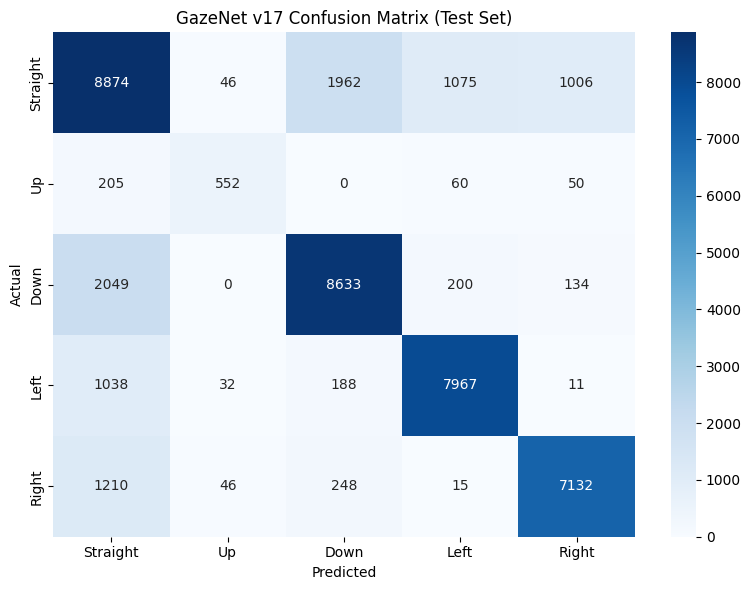


Test Set Performance
              precision    recall  f1-score   support

    Straight       0.66      0.68      0.67     12963
          Up       0.82      0.64      0.72       867
        Down       0.78      0.78      0.78     11016
        Left       0.86      0.86      0.86      9236
       Right       0.86      0.82      0.84      8651

    accuracy                           0.78     42733
   macro avg       0.79      0.76      0.77     42733
weighted avg       0.78      0.78      0.78     42733



In [20]:
# ============================================================
# TEST EVALUATION & CONFUSION MATRIX
# Load best checkpoint, run on test set, print classification
# report and confusion matrix — same as v16A.
# ============================================================

# Load best model
model.load_state_dict(torch.load(CHECKPOINT_PATH))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        left_eye     = batch['left_eye'].to(device)
        right_eye    = batch['right_eye'].to(device)
        face         = batch['face'].to(device)
        geo_features = batch['geo_features'].to(device)
        labels       = batch['label'].to(device)

        outputs = model(left_eye, right_eye, face, geo_features)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# ---- Confusion Matrix ----
label_names = ['Straight', 'Up', 'Down', 'Left', 'Right']
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('GazeNet v17 Confusion Matrix (Test Set)')
plt.tight_layout()
plt.show()

# ---- Classification Report ----
print("\n" + "="*50)
print("Test Set Performance")
print("="*50)
print(classification_report(all_labels, all_preds, target_names=label_names))

# m3

## WHAT CHANGED IN THIS RUN

**Changes:**
- FC layers shrunk: 11584→512→256→5 becomes 11584→256→128→5
- FC dropout increased: 0.5 → 0.7
- Kept label smoothing from m2

**Because:**
The FC layers contain 6M of the model's 6.5M total params — that's where memorization is happening. The CNN extracts features, but the massive FC block has enough capacity to memorize the training set rather than learning generalizable decision boundaries. Shrinking the FC layers cuts that capacity roughly in half, and increasing dropout forces the model to rely on more robust feature combinations rather than memorizing specific patterns.

In [21]:
# ============================================================
# GazeNet m3 — Stronger FC regularization
#
# Changes from m2:
#   - FC layers shrunk: 512→256→5 becomes 256→128→5
#   - Dropout increased: 0.5 → 0.7
#   - Everything else identical
# ============================================================

class GazeNetV17b(nn.Module):
    def __init__(self, num_classes=5, geo_feat_dim=7):
        super(GazeNetV17b, self).__init__()

        # ---- Eye CNN (UNCHANGED) ----
        self.eye_cnn = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        # ---- Face CNN (UNCHANGED) ----
        self.face_cnn = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=7, stride=2, padding=3),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        # ---- Geo MLP (UNCHANGED) ----
        self.geo_mlp = nn.Sequential(
            nn.Linear(geo_feat_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 64),
            nn.ReLU(),
        )

        # ---- FC classifier (CHANGED) ----
        # Was: 11584 → 512 → 256 → 5, dropout 0.5  (~6M params)
        # Now: 11584 → 256 → 128 → 5, dropout 0.7  (~3M params)
        self.fc = nn.Sequential(
            nn.Linear(4608 * 2 + 2304 + 64, 256),   # 11584 → 256 (was 512)
            nn.ReLU(),
            nn.Dropout(0.7),                          # was 0.5

            nn.Linear(256, 128),                      # 256 → 128 (was 256)
            nn.ReLU(),
            nn.Dropout(0.7),                          # was 0.5

            nn.Linear(128, num_classes),               # 128 → 5
        )

    def forward(self, left_eye, right_eye, face, geo_features):
        left_feat  = self.eye_cnn(left_eye).view(left_eye.size(0), -1)
        right_feat = self.eye_cnn(right_eye).view(right_eye.size(0), -1)
        face_feat  = self.face_cnn(face).view(face.size(0), -1)
        geo_feat   = self.geo_mlp(geo_features)

        combined = torch.cat([left_feat, right_feat, face_feat, geo_feat], dim=1)
        return self.fc(combined)

# Quick check
model_test = GazeNetV17b(num_classes=5)
print(f"V17b parameters: {sum(p.numel() for p in model_test.parameters()):,}")
print(f"  FC params: {sum(p.numel() for p in model_test.fc.parameters()):,}")

V17b parameters: 3,522,245
  FC params: 2,999,301


In [22]:
# ============================================================
# m3: Stronger FC regularization
# Same data, loaders, transforms — just new model and checkpoint
# ============================================================

MODEL_NAME = "m3"
CHECKPOINT_PATH = f'/content/drive/MyDrive/210/{MODEL_NAME}.pth'

model = GazeNetV17b(num_classes=5).to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)  # keep label smoothing too

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=5e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.5
)

print(f"Model: {MODEL_NAME}")
print(f"Using device: {device}")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"  FC params: {sum(p.numel() for p in model.fc.parameters()):,}")

Model: m3
Using device: cuda
Parameters: 3,522,245
  FC params: 2,999,301


In [23]:
# ============================================================
# TRAINING LOOP
#
# Same structure as v16A with two changes:
#   1. geo_features extracted from batch and passed to model
#   2. Model checkpoint saved as best_gazenet_v17.pth
# ============================================================

num_epochs = 20
best_val_loss = float('inf')

# Early stopping
patience = 6
patience_counter = 0

# Track metrics for loss curves
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):
    print(f"\n{'='*50}")
    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"{'='*50}")

    # ============================================
    # TRAINING PHASE
    # ============================================
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    epoch_start = time.time()

    for batch_idx, batch in enumerate(train_loader):
        # Move data to device
        left_eye     = batch['left_eye'].to(device)
        right_eye    = batch['right_eye'].to(device)
        face         = batch['face'].to(device)
        geo_features = batch['geo_features'].to(device)
        labels       = batch['label'].to(device)

        # Forward pass
        optimizer.zero_grad()
        outputs = model(left_eye, right_eye, face, geo_features)
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()
        optimizer.step()

        # Track metrics
        train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

        # Print progress every 1000 batches
        if (batch_idx + 1) % 1000 == 0:
            elapsed = time.time() - epoch_start
            batches_done = batch_idx + 1
            eta_minutes = (elapsed / batches_done) * (7000 - batches_done) / 60
            print(f"  Batch {batches_done}/~7000 - Loss: {loss.item():.4f} - ETA: {eta_minutes:.1f} min")

    # Calculate training metrics
    avg_train_loss = train_loss / (batch_idx + 1)
    train_acc = 100 * train_correct / train_total
    epoch_time = time.time() - epoch_start

    # ============================================
    # VALIDATION PHASE
    # ============================================
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    val_batch_count = 0

    with torch.no_grad():
        for batch in val_loader:
            val_batch_count += 1
            left_eye     = batch['left_eye'].to(device)
            right_eye    = batch['right_eye'].to(device)
            face         = batch['face'].to(device)
            geo_features = batch['geo_features'].to(device)
            labels       = batch['label'].to(device)

            outputs = model(left_eye, right_eye, face, geo_features)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    # Calculate validation metrics
    avg_val_loss = val_loss / val_batch_count
    val_acc = 100 * val_correct / val_total

    # Save metrics
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    # Step scheduler
    scheduler.step(avg_val_loss)

    # Print epoch summary
    print(f"\n  Time: {epoch_time/60:.1f} min")
    print(f"  Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"  Val Loss:   {avg_val_loss:.4f} | Val Acc:   {val_acc:.2f}%")
    print(f"  Gap: {train_acc - val_acc:.2f}%")

    # Save best model
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), CHECKPOINT_PATH)
        print(f"  Saved best model (val_loss={avg_val_loss:.4f})")
        patience_counter = 0
    else:
        patience_counter += 1
        print(f"  No improvement ({patience_counter}/{patience})")

    # Early stopping
    if patience_counter >= patience:
        print(f"\nEarly stopping triggered at epoch {epoch+1}")
        break

print(f"\nTraining complete!")
print(f"Best validation loss: {best_val_loss:.4f}")


Epoch 1/20
  Batch 1000/~7000 - Loss: 1.3593 - ETA: 12.4 min
  Batch 2000/~7000 - Loss: 1.0216 - ETA: 10.4 min
  Batch 3000/~7000 - Loss: 0.8868 - ETA: 8.3 min
  Batch 4000/~7000 - Loss: 1.0819 - ETA: 6.1 min
  Batch 5000/~7000 - Loss: 1.0301 - ETA: 4.0 min
  Batch 6000/~7000 - Loss: 0.9390 - ETA: 2.0 min

  Time: 12.3 min
  Train Loss: 1.1391 | Train Acc: 59.38%
  Val Loss:   0.9344 | Val Acc:   71.92%
  Gap: -12.54%
  Saved best model (val_loss=0.9344)

Epoch 2/20
  Batch 1000/~7000 - Loss: 0.9651 - ETA: 12.4 min
  Batch 2000/~7000 - Loss: 0.9429 - ETA: 10.3 min
  Batch 3000/~7000 - Loss: 1.0389 - ETA: 8.2 min
  Batch 4000/~7000 - Loss: 0.9626 - ETA: 6.1 min
  Batch 5000/~7000 - Loss: 0.9051 - ETA: 4.0 min
  Batch 6000/~7000 - Loss: 0.7756 - ETA: 2.0 min

  Time: 12.3 min
  Train Loss: 0.9444 | Train Acc: 72.33%
  Val Loss:   0.8780 | Val Acc:   73.76%
  Gap: -1.44%
  Saved best model (val_loss=0.8780)

Epoch 3/20
  Batch 1000/~7000 - Loss: 0.6687 - ETA: 12.5 min
  Batch 2000/~7000 

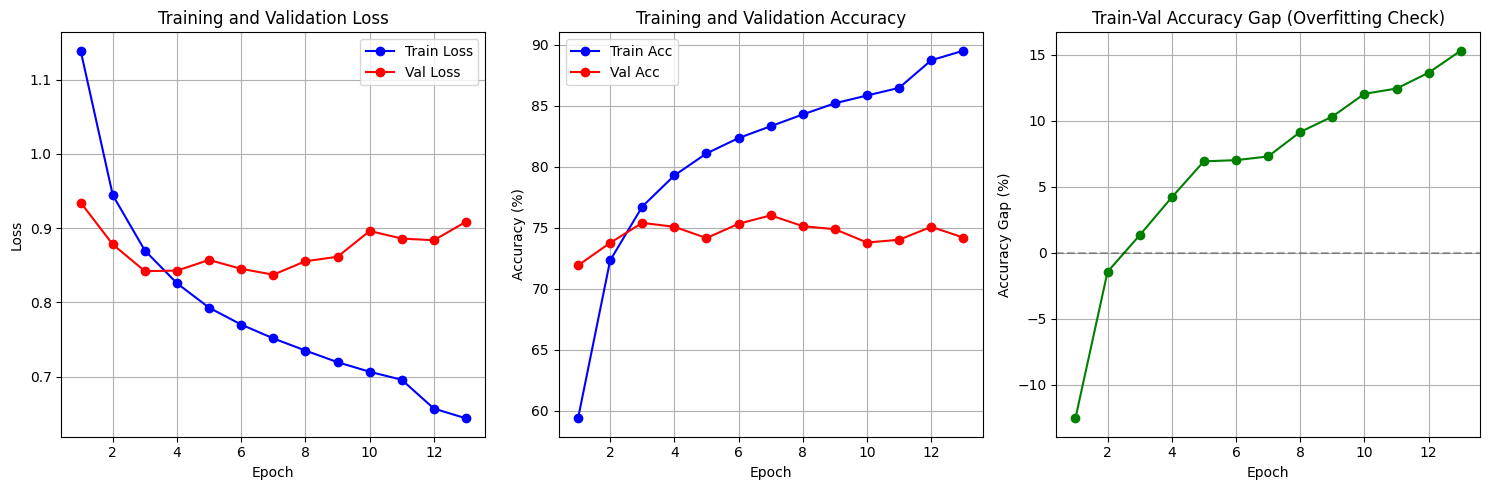


Training Summary
Total epochs completed: 13
Best validation loss: 0.8372 (Epoch 7)
Best validation accuracy: 76.02% (Epoch 7)
Final train accuracy: 89.52%
Final val accuracy: 74.20%
Final train-val gap: 15.32%


In [24]:
# ============================================================
# LOSS CURVES
# Same plots as v16A: loss, accuracy, and train-val gap
# ============================================================

plt.figure(figsize=(15, 5))

# ---- Loss ----
plt.subplot(1, 3, 1)
plt.plot(range(1, len(train_losses) + 1), train_losses, 'b-o', label='Train Loss')
plt.plot(range(1, len(val_losses) + 1), val_losses, 'r-o', label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

# ---- Accuracy ----
plt.subplot(1, 3, 2)
plt.plot(range(1, len(train_accuracies) + 1), train_accuracies, 'b-o', label='Train Acc')
plt.plot(range(1, len(val_accuracies) + 1), val_accuracies, 'r-o', label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)

# ---- Overfitting gap ----
plt.subplot(1, 3, 3)
gap = [train_accuracies[i] - val_accuracies[i] for i in range(len(train_accuracies))]
plt.plot(range(1, len(gap) + 1), gap, 'g-o')
plt.xlabel('Epoch')
plt.ylabel('Accuracy Gap (%)')
plt.title('Train-Val Accuracy Gap (Overfitting Check)')
plt.axhline(y=0, color='k', linestyle='--', alpha=0.3)
plt.grid(True)

plt.tight_layout()
plt.show()

# ---- Summary ----
print("\n" + "="*50)
print("Training Summary")
print("="*50)
print(f"Total epochs completed: {len(train_losses)}")
print(f"Best validation loss: {min(val_losses):.4f} (Epoch {val_losses.index(min(val_losses)) + 1})")
print(f"Best validation accuracy: {max(val_accuracies):.2f}% (Epoch {val_accuracies.index(max(val_accuracies)) + 1})")
print(f"Final train accuracy: {train_accuracies[-1]:.2f}%")
print(f"Final val accuracy: {val_accuracies[-1]:.2f}%")
print(f"Final train-val gap: {train_accuracies[-1] - val_accuracies[-1]:.2f}%")
print("="*50)

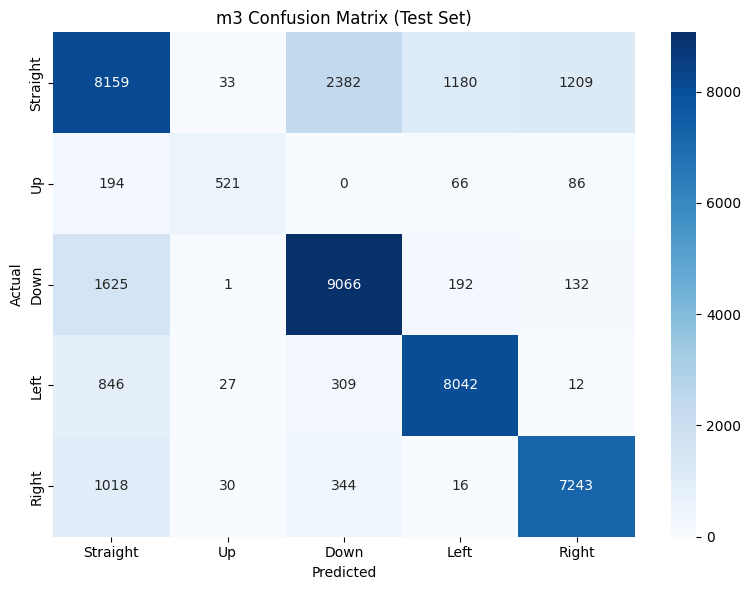


m3 Test Set Performance
              precision    recall  f1-score   support

    Straight       0.69      0.63      0.66     12963
          Up       0.85      0.60      0.70       867
        Down       0.75      0.82      0.78     11016
        Left       0.85      0.87      0.86      9236
       Right       0.83      0.84      0.84      8651

    accuracy                           0.77     42733
   macro avg       0.79      0.75      0.77     42733
weighted avg       0.77      0.77      0.77     42733



In [25]:
# ============================================================
# TEST EVALUATION & CONFUSION MATRIX
# ============================================================

model.load_state_dict(torch.load(CHECKPOINT_PATH))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        left_eye     = batch['left_eye'].to(device)
        right_eye    = batch['right_eye'].to(device)
        face         = batch['face'].to(device)
        geo_features = batch['geo_features'].to(device)
        labels       = batch['label'].to(device)

        outputs = model(left_eye, right_eye, face, geo_features)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# ---- Confusion Matrix ----
label_names = ['Straight', 'Up', 'Down', 'Left', 'Right']
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'{MODEL_NAME} Confusion Matrix (Test Set)')
plt.tight_layout()
plt.show()

# ---- Classification Report ----
print("\n" + "="*50)
print(f"{MODEL_NAME} Test Set Performance")
print("="*50)
print(classification_report(all_labels, all_preds, target_names=label_names))

# m4

## WHAT CHANGED IN THIS RUN

**Changes:**
- Two-phase training: all parameters train normally until val loss plateaus, then CNN freezes and only geo MLP + FC continue training
- Freeze triggered automatically when val loss hasn't improved in 3 epochs (same signal as LR scheduler)
- Early stopping resets after freeze to give phase 2 a fair chance
- Using GazeNetV17 (original FC) — m3 showed smaller FC hurts accuracy
- Keeping label smoothing (0.1) — m2 showed it buys 2-3 more epochs before overfitting

**Because:**
The geo MLP has only 4,672 params but the CNN has 611K. During normal training, the CNN learns fast and starts memorizing by epoch 2-3, which means the best checkpoint is saved before the geo MLP has had enough time to learn meaningful representations from the geometric features. Freezing the CNN once it stops improving lets the geo MLP and FC continue refining their weights without the CNN dragging the model into overfitting. The freeze is triggered by val loss plateau rather than an arbitrary epoch number so the model decides when it's ready.

In [26]:
# ============================================================
# GazeNet m4 — Same architecture as m1/m2 (GazeNetV17)
# Defined here so this section is self-contained.
# The only change in m4 is the training strategy (CNN freezing),
# not the model architecture.
# ============================================================

class GazeNetM4(nn.Module):
    def __init__(self, num_classes=5, geo_feat_dim=7):
        super(GazeNetM4, self).__init__()

        # ---- Eye CNN (shared weights for left and right) ----
        self.eye_cnn = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        # ---- Face CNN ----
        self.face_cnn = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=7, stride=2, padding=3),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        # ---- Geometric feature branch ----
        self.geo_mlp = nn.Sequential(
            nn.Linear(geo_feat_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 64),
            nn.ReLU(),
        )

        # ---- FC classifier (original size, same as m1/m2) ----
        self.fc = nn.Sequential(
            nn.Linear(4608 * 2 + 2304 + 64, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, left_eye, right_eye, face, geo_features):
        left_feat  = self.eye_cnn(left_eye).view(left_eye.size(0), -1)
        right_feat = self.eye_cnn(right_eye).view(right_eye.size(0), -1)
        face_feat  = self.face_cnn(face).view(face.size(0), -1)
        geo_feat   = self.geo_mlp(geo_features)

        combined = torch.cat([left_feat, right_feat, face_feat, geo_feat], dim=1)
        return self.fc(combined)

print("GazeNetM4 defined")

GazeNetM4 defined


In [27]:
# ============================================================
# GazeNet m4 — CNN Freezing triggered by val loss plateau
#
# Two-phase training:
#   Phase 1: Train everything (CNN + geo MLP + FC) normally
#   Phase 2: When val loss stops improving, freeze CNN weights
#            and continue training only geo MLP + FC
#
# The freeze trigger uses the same signal as the LR scheduler:
#   if val loss hasn't improved in FREEZE_PATIENCE epochs, freeze.
#
# Decisions based on m2 and m3 results:
#   - GazeNetV17 (original FC) — m3 showed smaller FC hurts accuracy
#   - Label smoothing ON (0.1) — m2 showed it buys 2-3 more epochs
#   - Freeze patience 3 — same as LR scheduler patience
# ============================================================

MODEL_CLASS = GazeNetM4
LABEL_SMOOTHING = 0.1
FREEZE_PATIENCE = 3

MODEL_NAME = "m4"
CHECKPOINT_PATH = f'/content/drive/MyDrive/210/{MODEL_NAME}.pth'

In [28]:
# ============================================================
# m4 TRAINING LOOP — Two-phase with CNN freezing
#
# Phase 1: All parameters train normally
# Phase 2: CNN frozen, only geo_mlp + fc train
#
# Transition happens when val loss hasn't improved
# in FREEZE_PATIENCE epochs.
# ============================================================

import time

model = MODEL_CLASS(num_classes=5).to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.5
)

num_epochs = 20
best_val_loss = float('inf')

# Early stopping (kills training entirely)
patience = 6
patience_counter = 0

# CNN freeze tracking (transitions from phase 1 → phase 2)
freeze_counter = 0
cnn_frozen = False

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):
    print(f"\n{'='*50}")
    phase_str = "PHASE 2 (CNN frozen)" if cnn_frozen else "PHASE 1 (all training)"
    print(f"Epoch {epoch+1}/{num_epochs} — {phase_str}")
    print(f"{'='*50}")

    # ============================================
    # TRAINING PHASE
    # ============================================
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    epoch_start = time.time()

    for batch_idx, batch in enumerate(train_loader):
        left_eye     = batch['left_eye'].to(device)
        right_eye    = batch['right_eye'].to(device)
        face         = batch['face'].to(device)
        geo_features = batch['geo_features'].to(device)
        labels       = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(left_eye, right_eye, face, geo_features)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

        if (batch_idx + 1) % 1000 == 0:
            elapsed = time.time() - epoch_start
            batches_done = batch_idx + 1
            eta_minutes = (elapsed / batches_done) * (7000 - batches_done) / 60
            print(f"  Batch {batches_done}/~7000 - Loss: {loss.item():.4f} - ETA: {eta_minutes:.1f} min")

    avg_train_loss = train_loss / (batch_idx + 1)
    train_acc = 100 * train_correct / train_total
    epoch_time = time.time() - epoch_start

    # ============================================
    # VALIDATION PHASE
    # ============================================
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    val_batch_count = 0

    with torch.no_grad():
        for batch in val_loader:
            val_batch_count += 1
            left_eye     = batch['left_eye'].to(device)
            right_eye    = batch['right_eye'].to(device)
            face         = batch['face'].to(device)
            geo_features = batch['geo_features'].to(device)
            labels       = batch['label'].to(device)

            outputs = model(left_eye, right_eye, face, geo_features)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    avg_val_loss = val_loss / val_batch_count
    val_acc = 100 * val_correct / val_total

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    scheduler.step(avg_val_loss)

    print(f"\n  Time: {epoch_time/60:.1f} min")
    print(f"  Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"  Val Loss:   {avg_val_loss:.4f} | Val Acc:   {val_acc:.2f}%")
    print(f"  Gap: {train_acc - val_acc:.2f}%")

    # ============================================
    # CHECKPOINT: Save best model
    # ============================================
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), CHECKPOINT_PATH)
        print(f"  Saved best model (val_loss={avg_val_loss:.4f})")
        patience_counter = 0
        freeze_counter = 0   # reset freeze counter too
    else:
        patience_counter += 1
        freeze_counter += 1

        # ==============================================
        # CNN FREEZE CHECK
        # If val loss hasn't improved in FREEZE_PATIENCE
        # epochs and we haven't frozen yet, freeze now.
        # ==============================================
        if not cnn_frozen and freeze_counter >= FREEZE_PATIENCE:
            print(f"\n  *** FREEZING CNN WEIGHTS ***")
            print(f"  Val loss hasn't improved in {FREEZE_PATIENCE} epochs")
            print(f"  Only geo_mlp and fc will train from here")

            # Freeze eye CNN and face CNN
            for param in model.eye_cnn.parameters():
                param.requires_grad = False
            for param in model.face_cnn.parameters():
                param.requires_grad = False

            cnn_frozen = True

            # Rebuild optimizer with only unfrozen params
            # This also resets momentum/adaptive state which is what we want
            optimizer = torch.optim.Adam(
                filter(lambda p: p.requires_grad, model.parameters()),
                lr=1e-4, weight_decay=5e-4
            )
            scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                optimizer, mode='min', patience=3, factor=0.5
            )

            # Reset early stopping to give phase 2 a fair chance
            patience_counter = 0
            print(f"  Early stopping counter reset for phase 2\n")

        else:
            print(f"  No improvement ({patience_counter}/{patience})")

    # ============================================
    # EARLY STOPPING
    # ============================================
    if patience_counter >= patience:
        print(f"\nEarly stopping triggered at epoch {epoch+1}")
        break

print(f"\nTraining complete!")
print(f"Best validation loss: {best_val_loss:.4f}")
print(f"CNN was frozen: {cnn_frozen}")


Epoch 1/20 — PHASE 1 (all training)
  Batch 1000/~7000 - Loss: 1.0557 - ETA: 12.7 min
  Batch 2000/~7000 - Loss: 0.9830 - ETA: 10.5 min
  Batch 3000/~7000 - Loss: 0.8822 - ETA: 8.4 min
  Batch 4000/~7000 - Loss: 1.1080 - ETA: 6.1 min
  Batch 5000/~7000 - Loss: 1.0741 - ETA: 4.0 min
  Batch 6000/~7000 - Loss: 0.7370 - ETA: 2.0 min

  Time: 12.6 min
  Train Loss: 0.9908 | Train Acc: 67.68%
  Val Loss:   0.8817 | Val Acc:   73.64%
  Gap: -5.96%
  Saved best model (val_loss=0.8817)

Epoch 2/20 — PHASE 1 (all training)
  Batch 1000/~7000 - Loss: 0.7565 - ETA: 12.5 min
  Batch 2000/~7000 - Loss: 0.7864 - ETA: 10.5 min
  Batch 3000/~7000 - Loss: 0.8153 - ETA: 8.3 min
  Batch 4000/~7000 - Loss: 0.7409 - ETA: 6.1 min
  Batch 5000/~7000 - Loss: 0.7242 - ETA: 4.1 min
  Batch 6000/~7000 - Loss: 0.7288 - ETA: 2.0 min

  Time: 12.7 min
  Train Loss: 0.8216 | Train Acc: 77.65%
  Val Loss:   0.8404 | Val Acc:   75.35%
  Gap: 2.30%
  Saved best model (val_loss=0.8404)

Epoch 3/20 — PHASE 1 (all traini

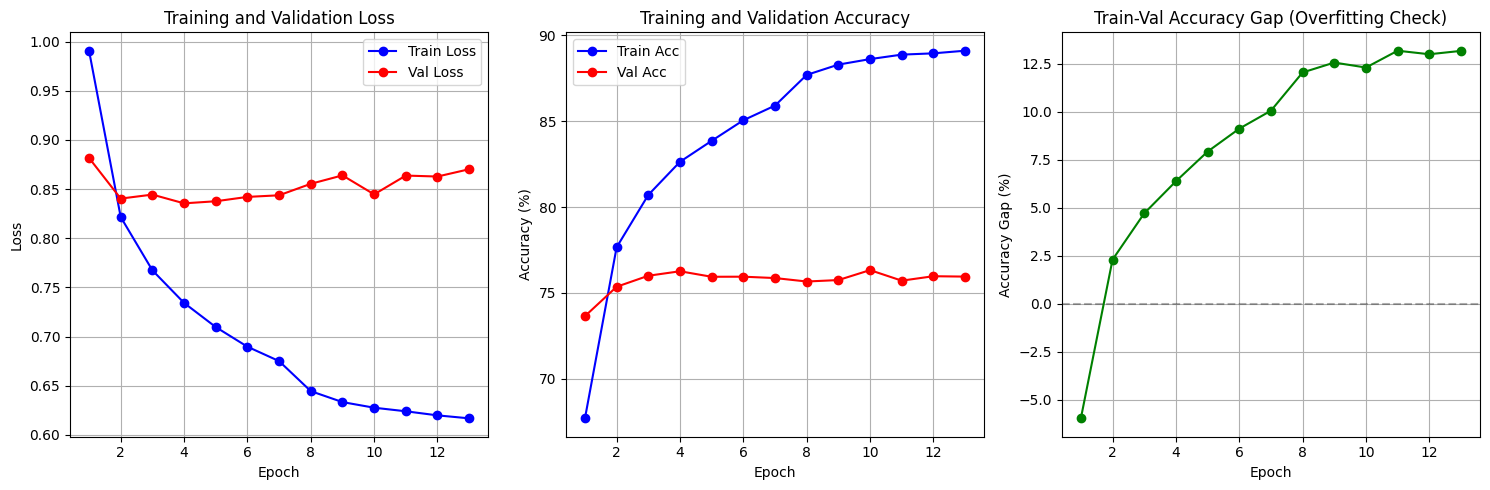


Training Summary
Total epochs completed: 13
Best validation loss: 0.8355 (Epoch 4)
Best validation accuracy: 76.32% (Epoch 10)
Final train accuracy: 89.11%
Final val accuracy: 75.95%
Final train-val gap: 13.17%


In [29]:
# ============================================================
# LOSS CURVES
# Same plots as v16A: loss, accuracy, and train-val gap
# ============================================================

plt.figure(figsize=(15, 5))

# ---- Loss ----
plt.subplot(1, 3, 1)
plt.plot(range(1, len(train_losses) + 1), train_losses, 'b-o', label='Train Loss')
plt.plot(range(1, len(val_losses) + 1), val_losses, 'r-o', label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

# ---- Accuracy ----
plt.subplot(1, 3, 2)
plt.plot(range(1, len(train_accuracies) + 1), train_accuracies, 'b-o', label='Train Acc')
plt.plot(range(1, len(val_accuracies) + 1), val_accuracies, 'r-o', label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)

# ---- Overfitting gap ----
plt.subplot(1, 3, 3)
gap = [train_accuracies[i] - val_accuracies[i] for i in range(len(train_accuracies))]
plt.plot(range(1, len(gap) + 1), gap, 'g-o')
plt.xlabel('Epoch')
plt.ylabel('Accuracy Gap (%)')
plt.title('Train-Val Accuracy Gap (Overfitting Check)')
plt.axhline(y=0, color='k', linestyle='--', alpha=0.3)
plt.grid(True)

plt.tight_layout()
plt.show()

# ---- Summary ----
print("\n" + "="*50)
print("Training Summary")
print("="*50)
print(f"Total epochs completed: {len(train_losses)}")
print(f"Best validation loss: {min(val_losses):.4f} (Epoch {val_losses.index(min(val_losses)) + 1})")
print(f"Best validation accuracy: {max(val_accuracies):.2f}% (Epoch {val_accuracies.index(max(val_accuracies)) + 1})")
print(f"Final train accuracy: {train_accuracies[-1]:.2f}%")
print(f"Final val accuracy: {val_accuracies[-1]:.2f}%")
print(f"Final train-val gap: {train_accuracies[-1] - val_accuracies[-1]:.2f}%")
print("="*50)

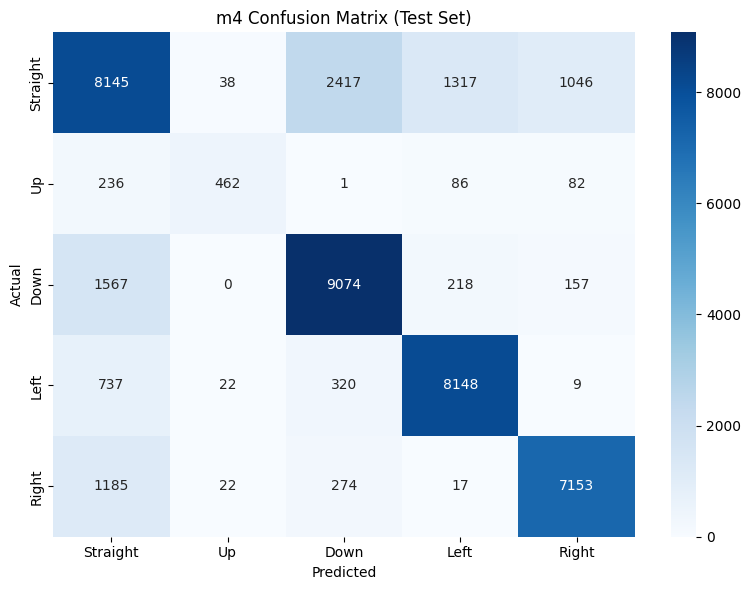


m4 Test Set Performance
              precision    recall  f1-score   support

    Straight       0.69      0.63      0.66     12963
          Up       0.85      0.53      0.65       867
        Down       0.75      0.82      0.79     11016
        Left       0.83      0.88      0.86      9236
       Right       0.85      0.83      0.84      8651

    accuracy                           0.77     42733
   macro avg       0.79      0.74      0.76     42733
weighted avg       0.77      0.77      0.77     42733



In [30]:
# ============================================================
# TEST EVALUATION & CONFUSION MATRIX
# ============================================================

model.load_state_dict(torch.load(CHECKPOINT_PATH))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        left_eye     = batch['left_eye'].to(device)
        right_eye    = batch['right_eye'].to(device)
        face         = batch['face'].to(device)
        geo_features = batch['geo_features'].to(device)
        labels       = batch['label'].to(device)

        outputs = model(left_eye, right_eye, face, geo_features)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# ---- Confusion Matrix ----
label_names = ['Straight', 'Up', 'Down', 'Left', 'Right']
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'{MODEL_NAME} Confusion Matrix (Test Set)')
plt.tight_layout()
plt.show()

# ---- Classification Report ----
print("\n" + "="*50)
print(f"{MODEL_NAME} Test Set Performance")
print("="*50)
print(classification_report(all_labels, all_preds, target_names=label_names))

# m5

## WHAT CHANGED IN THIS RUN

**Changes:**
- Dropped Straight class entirely — 4 classes (Up, Down, Left, Right) instead of 5
- Straight samples filtered out during data loading, not seen by the model at all
- num_classes=4 in model output layer
- Architecture otherwise identical to m1 (GazeNetV17 with geo features, original FC size)
- Keeping label smoothing (0.1)

**Because:**
Straight is the #1 source of errors across every model run. It accounts for ~8,000 misclassifications per run — Straight↔Down (~4,000), Straight↔Left (~2,000), Straight↔Right (~2,000). The decision boundary between "slightly looking left" and "looking straight" is genuinely ambiguous in the data, and the model is spending most of its capacity (and overfitting) trying to learn that impossible boundary.

From a use case perspective, Straight doesn't map to an action — the app has directional buttons (Up, Down, Left, Right) and Straight means "not selecting anything." That can be handled with a confidence threshold on the 4-class model instead of a dedicated class. If no direction gets above a threshold, treat it as no selection. This is actually more robust because it lets you tune sensitivity at deployment time rather than baking it into the model.

In [31]:
# ============================================================
# m5 — 4-class model (drop Straight)
#
# Changes:
#   - Remove Straight from label_map and label_lookup
#   - num_classes=4 instead of 5
#   - Everything else identical to m1
#
# Hypothesis: Straight is the #1 source of errors and its
# decision boundary is genuinely ambiguous. Removing it
# should boost accuracy on the remaining classes AND
# reduce overfitting since the model no longer needs to
# memorize to distinguish "slightly left" from "straight."
# ============================================================

# ---- Override label_map to 4 classes ----
# (original label_lookup is still in memory from earlier)
label_map_4 = {'Up': 0, 'Down': 1, 'Left': 2, 'Right': 3}

# ---- Build a filtered lookup that excludes Straight ----
label_lookup_4 = {k: v for k, v in label_lookup.items() if v != 'Straight'}
print(f"Original label_lookup: {len(label_lookup)} entries")
print(f"Filtered (no Straight): {len(label_lookup_4)} entries")
print(f"Dropped: {len(label_lookup) - len(label_lookup_4)} Straight samples")

Original label_lookup: 849131 entries
Filtered (no Straight): 602467 entries
Dropped: 246664 Straight samples


In [32]:
# ============================================================
# make_dataset for 4-class model
# Only change: uses label_map_4 and label_lookup_4
# Straight samples return None and get filtered out
# ============================================================

def make_dataset_4class(tar_urls, eye_transform, face_transform, shuffle=True):

    def filter_and_transform(sample):
        key = sample["__key__"]

        # ---- Skip Straight samples entirely ----
        label_str = label_lookup_4.get(key)
        if label_str is None:
            return None

        face = np.array(sample["face.jpg"])
        left_eye = np.array(sample["left.jpg"])
        right_eye = np.array(sample["right.jpg"])

        if eye_transform:
            left_eye = eye_transform(left_eye)
            right_eye = eye_transform(right_eye)
        if face_transform:
            face = face_transform(face)

        geo_features = geo_lookup.get(key)
        if geo_features is None:
            geo_features = GEO_DEFAULT.copy()

        label_idx = label_map_4[label_str]

        return {
            'left_eye': left_eye,
            'right_eye': right_eye,
            'face': face,
            'geo_features': torch.tensor(geo_features, dtype=torch.float32),
            'label': torch.tensor(label_idx, dtype=torch.long),
        }

    dataset = (
        wds.WebDataset(tar_urls, shardshuffle=1000 if shuffle else False)
        .shuffle(50000 if shuffle else 0)
        .decode("pil")
        .map(filter_and_transform)
        .select(lambda x: x is not None)
    )

    return dataset

print("make_dataset_4class defined")

make_dataset_4class defined


In [33]:
# ============================================================
# m5 setup
# ============================================================

MODEL_NAME = "m5"
CHECKPOINT_PATH = f'/content/drive/MyDrive/210/{MODEL_NAME}.pth'

# ---- New loaders using 4-class dataset ----
train_dataset = make_dataset_4class(train_tar_urls, eye_transform_aug,   face_transform_aug,   shuffle=True)
val_dataset   = make_dataset_4class(val_tar_urls,   eye_transform_clean, face_transform_clean, shuffle=False)
test_dataset  = make_dataset_4class(test_tar_urls,  eye_transform_clean, face_transform_clean, shuffle=False)

train_loader = wds.WebLoader(train_dataset, batch_size=32, num_workers=2, pin_memory=True)
val_loader   = wds.WebLoader(val_dataset,   batch_size=32, num_workers=2, pin_memory=True)
test_loader  = wds.WebLoader(test_dataset,  batch_size=32, num_workers=2, pin_memory=True)

# ---- Model with 4 classes ----
model = GazeNetV17(num_classes=4).to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.5
)

print(f"Model: {MODEL_NAME}")
print(f"Using device: {device}")
print(f"Classes: {list(label_map_4.keys())}")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Model: m5
Using device: cuda
Classes: ['Up', 'Down', 'Left', 'Right']
Parameters: 6,586,820


In [34]:
# ============================================================
# m5 TRAINING LOOP
# ============================================================
model = MODEL_CLASS(num_classes=5).to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.5
)

num_epochs = 20
best_val_loss = float('inf')

# Early stopping (kills training entirely)
patience = 6
patience_counter = 0

# CNN freeze tracking (transitions from phase 1 → phase 2)
freeze_counter = 0
cnn_frozen = False

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):
    print(f"\n{'='*50}")
    phase_str = "PHASE 2 (CNN frozen)" if cnn_frozen else "PHASE 1 (all training)"
    print(f"Epoch {epoch+1}/{num_epochs} — {phase_str}")
    print(f"{'='*50}")

    # ============================================
    # TRAINING PHASE
    # ============================================
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    epoch_start = time.time()

    for batch_idx, batch in enumerate(train_loader):
        left_eye     = batch['left_eye'].to(device)
        right_eye    = batch['right_eye'].to(device)
        face         = batch['face'].to(device)
        geo_features = batch['geo_features'].to(device)
        labels       = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(left_eye, right_eye, face, geo_features)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

        if (batch_idx + 1) % 1000 == 0:
            elapsed = time.time() - epoch_start
            batches_done = batch_idx + 1
            eta_minutes = (elapsed / batches_done) * (7000 - batches_done) / 60
            print(f"  Batch {batches_done}/~7000 - Loss: {loss.item():.4f} - ETA: {eta_minutes:.1f} min")

    avg_train_loss = train_loss / (batch_idx + 1)
    train_acc = 100 * train_correct / train_total
    epoch_time = time.time() - epoch_start

    # ============================================
    # VALIDATION PHASE
    # ============================================
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    val_batch_count = 0

    with torch.no_grad():
        for batch in val_loader:
            val_batch_count += 1
            left_eye     = batch['left_eye'].to(device)
            right_eye    = batch['right_eye'].to(device)
            face         = batch['face'].to(device)
            geo_features = batch['geo_features'].to(device)
            labels       = batch['label'].to(device)

            outputs = model(left_eye, right_eye, face, geo_features)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    avg_val_loss = val_loss / val_batch_count
    val_acc = 100 * val_correct / val_total

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    scheduler.step(avg_val_loss)

    print(f"\n  Time: {epoch_time/60:.1f} min")
    print(f"  Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"  Val Loss:   {avg_val_loss:.4f} | Val Acc:   {val_acc:.2f}%")
    print(f"  Gap: {train_acc - val_acc:.2f}%")

    # ============================================
    # CHECKPOINT: Save best model
    # ============================================
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), CHECKPOINT_PATH)
        print(f"  Saved best model (val_loss={avg_val_loss:.4f})")
        patience_counter = 0
        freeze_counter = 0   # reset freeze counter too
    else:
        patience_counter += 1
        freeze_counter += 1

        # ==============================================
        # CNN FREEZE CHECK
        # If val loss hasn't improved in FREEZE_PATIENCE
        # epochs and we haven't frozen yet, freeze now.
        # ==============================================
        if not cnn_frozen and freeze_counter >= FREEZE_PATIENCE:
            print(f"\n  *** FREEZING CNN WEIGHTS ***")
            print(f"  Val loss hasn't improved in {FREEZE_PATIENCE} epochs")
            print(f"  Only geo_mlp and fc will train from here")

            # Freeze eye CNN and face CNN
            for param in model.eye_cnn.parameters():
                param.requires_grad = False
            for param in model.face_cnn.parameters():
                param.requires_grad = False

            cnn_frozen = True

            # Rebuild optimizer with only unfrozen params
            # This also resets momentum/adaptive state which is what we want
            optimizer = torch.optim.Adam(
                filter(lambda p: p.requires_grad, model.parameters()),
                lr=1e-4, weight_decay=5e-4
            )
            scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                optimizer, mode='min', patience=3, factor=0.5
            )

            # Reset early stopping to give phase 2 a fair chance
            patience_counter = 0
            print(f"  Early stopping counter reset for phase 2\n")

        else:
            print(f"  No improvement ({patience_counter}/{patience})")

    # ============================================
    # EARLY STOPPING
    # ============================================
    if patience_counter >= patience:
        print(f"\nEarly stopping triggered at epoch {epoch+1}")
        break

print(f"\nTraining complete!")
print(f"Best validation loss: {best_val_loss:.4f}")
print(f"CNN was frozen: {cnn_frozen}")


Epoch 1/20 — PHASE 1 (all training)
  Batch 1000/~7000 - Loss: 0.7257 - ETA: 13.8 min
  Batch 2000/~7000 - Loss: 0.5883 - ETA: 11.4 min
  Batch 3000/~7000 - Loss: 0.5321 - ETA: 8.8 min
  Batch 4000/~7000 - Loss: 0.6980 - ETA: 6.5 min

  Time: 9.6 min
  Train Loss: 0.7039 | Train Acc: 85.56%
  Val Loss:   0.6003 | Val Acc:   90.04%
  Gap: -4.48%
  Saved best model (val_loss=0.6003)

Epoch 2/20 — PHASE 1 (all training)
  Batch 1000/~7000 - Loss: 0.4947 - ETA: 13.5 min
  Batch 2000/~7000 - Loss: 0.6077 - ETA: 11.3 min
  Batch 3000/~7000 - Loss: 0.4704 - ETA: 8.7 min
  Batch 4000/~7000 - Loss: 0.5175 - ETA: 6.4 min

  Time: 9.5 min
  Train Loss: 0.5516 | Train Acc: 93.37%
  Val Loss:   0.5783 | Val Acc:   90.78%
  Gap: 2.58%
  Saved best model (val_loss=0.5783)

Epoch 3/20 — PHASE 1 (all training)
  Batch 1000/~7000 - Loss: 0.5586 - ETA: 13.6 min
  Batch 2000/~7000 - Loss: 0.4759 - ETA: 11.3 min
  Batch 3000/~7000 - Loss: 0.5079 - ETA: 8.7 min
  Batch 4000/~7000 - Loss: 0.5947 - ETA: 6.4 

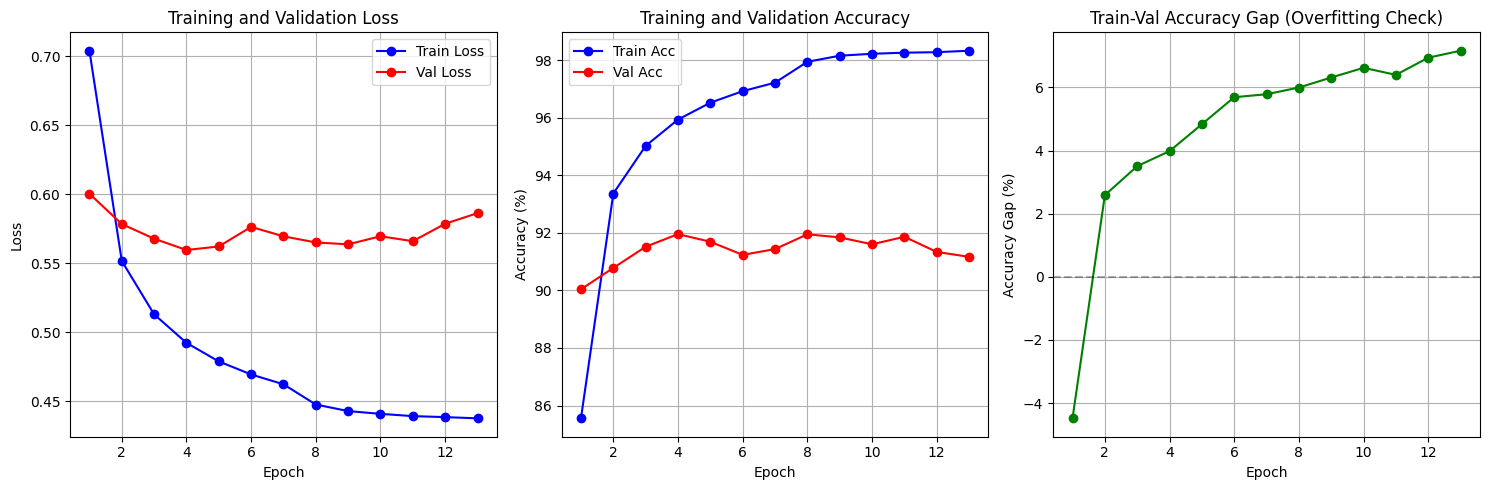


Training Summary
Total epochs completed: 13
Best validation loss: 0.5595 (Epoch 4)
Best validation accuracy: 91.96% (Epoch 4)
Final train accuracy: 98.33%
Final val accuracy: 91.17%
Final train-val gap: 7.16%


In [35]:
# ============================================================
# LOSS CURVES
# Same plots as v16A: loss, accuracy, and train-val gap
# ============================================================

plt.figure(figsize=(15, 5))

# ---- Loss ----
plt.subplot(1, 3, 1)
plt.plot(range(1, len(train_losses) + 1), train_losses, 'b-o', label='Train Loss')
plt.plot(range(1, len(val_losses) + 1), val_losses, 'r-o', label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

# ---- Accuracy ----
plt.subplot(1, 3, 2)
plt.plot(range(1, len(train_accuracies) + 1), train_accuracies, 'b-o', label='Train Acc')
plt.plot(range(1, len(val_accuracies) + 1), val_accuracies, 'r-o', label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)

# ---- Overfitting gap ----
plt.subplot(1, 3, 3)
gap = [train_accuracies[i] - val_accuracies[i] for i in range(len(train_accuracies))]
plt.plot(range(1, len(gap) + 1), gap, 'g-o')
plt.xlabel('Epoch')
plt.ylabel('Accuracy Gap (%)')
plt.title('Train-Val Accuracy Gap (Overfitting Check)')
plt.axhline(y=0, color='k', linestyle='--', alpha=0.3)
plt.grid(True)

plt.tight_layout()
plt.show()

# ---- Summary ----
print("\n" + "="*50)
print("Training Summary")
print("="*50)
print(f"Total epochs completed: {len(train_losses)}")
print(f"Best validation loss: {min(val_losses):.4f} (Epoch {val_losses.index(min(val_losses)) + 1})")
print(f"Best validation accuracy: {max(val_accuracies):.2f}% (Epoch {val_accuracies.index(max(val_accuracies)) + 1})")
print(f"Final train accuracy: {train_accuracies[-1]:.2f}%")
print(f"Final val accuracy: {val_accuracies[-1]:.2f}%")
print(f"Final train-val gap: {train_accuracies[-1] - val_accuracies[-1]:.2f}%")
print("="*50)

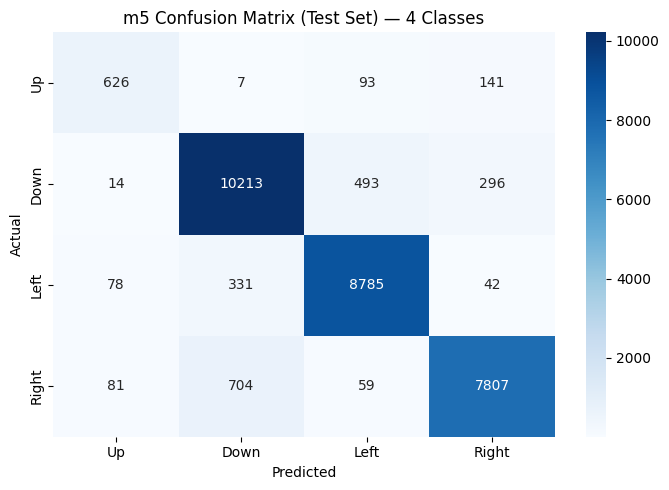


m5 Test Set Performance
              precision    recall  f1-score   support

          Up       0.78      0.72      0.75       867
        Down       0.91      0.93      0.92     11016
        Left       0.93      0.95      0.94      9236
       Right       0.94      0.90      0.92      8651

    accuracy                           0.92     29770
   macro avg       0.89      0.88      0.88     29770
weighted avg       0.92      0.92      0.92     29770



In [36]:
# ============================================================
# TEST EVALUATION & CONFUSION MATRIX — 4 classes
# ============================================================

model.load_state_dict(torch.load(CHECKPOINT_PATH))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        left_eye     = batch['left_eye'].to(device)
        right_eye    = batch['right_eye'].to(device)
        face         = batch['face'].to(device)
        geo_features = batch['geo_features'].to(device)
        labels       = batch['label'].to(device)

        outputs = model(left_eye, right_eye, face, geo_features)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# ---- 4-class labels ----
label_names = ['Up', 'Down', 'Left', 'Right']
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'{MODEL_NAME} Confusion Matrix (Test Set) — 4 Classes')
plt.tight_layout()
plt.show()

print("\n" + "="*50)
print(f"{MODEL_NAME} Test Set Performance")
print("="*50)
print(classification_report(all_labels, all_preds, target_names=label_names))